# Your First GLM with Aurora-GLM

**Topics:** GLM, Linear Regression, Model Fitting

## Overview

This quickstart notebook demonstrates how to fit your first Generalized Linear Model (GLM) using Aurora-GLM. We'll predict house prices based on simple features like area and number of bedrooms.

## What You'll Learn

- Generate synthetic data
- Fit a Gaussian GLM (linear regression)
- View model summary
- Make predictions
- Visualize results

---

## 1. Setup

Import necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora.models import fit_glm

# Set random seed for reproducibility
np.random.seed(42)

## 2. Generate Synthetic Data

Create a dataset of house prices with:
- `area`: House area in square feet
- `bedrooms`: Number of bedrooms
- `price`: House price in thousands of dollars (target variable)

In [2]:
# Generate 100 houses
n = 100

# Features
area = np.random.uniform(1000, 3000, n)  # sq ft
bedrooms = np.random.randint(1, 5, n)    # 1-4 bedrooms

# True relationship: price = 50 + 0.1*area + 20*bedrooms + noise
price = 50 + 0.1 * area + 20 * bedrooms + np.random.randn(n) * 15

# Create DataFrame
df = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'price': price
})

print(f"Generated {len(df)} houses")
df.head()

Generated 100 houses


,area,bedrooms,price
0,1749.080238,3,282.022609
1,2901.428613,4,424.666071
2,2463.987884,3,355.878112
3,2197.316968,1,272.201526
4,1312.037281,4,278.346070


## 3. Prepare Data for Modeling

Create design matrix (X) and response vector (y):

In [3]:
# Design matrix: intercept + features
X = np.column_stack([
    np.ones(n),      # Intercept
    df['area'],      # Area
    df['bedrooms']   # Bedrooms
])

# Response vector
y = df['price'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (100, 3)
y shape: (100,)


## 4. Fit the Model

Fit a Gaussian GLM (linear regression):

In [5]:
# Fit Gaussian GLM with identity link (linear regression)
result = fit_glm(
    X=X,
    y=y,
    family='gaussian'
)

print(f"Model converged: {result.converged_}")
print(f"Iterations: {result.n_iter_}")

Model converged: True
Iterations: 2


## 5. View Summary

Display model coefficients and statistics:

In [6]:
# Print formatted summary
print(result.summary())

                       Generalized Linear Model Results                       
Family:                   Gaussian                   Link function:  Identity
No. Observations:         100                        Df Residuals:   96
Df Model:                 3                         
Converged:                Yes                        No. Iterations: 2
                   coef    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
   intercept    25.5974  7071.0675      0.004      0.997 -13833.4403 13884.6351 
          X0    25.5974  7071.0675      0.004      0.997 -13833.4403 13884.6350 
          X1     0.1002     0.0002    590.574      0.000     0.0998     0.1005 ***
          X2    20.1012     0.0864    232.635      0.000    19.9319    20.2706 ***
Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Deviance:                             21663.58 Null Deviance:        403276.27
AIC:           

**Interpretation:**
- **Intercept:** Base price when area=0 and bedrooms=0
- **Area coefficient:** Each additional sq ft adds ~$0.10 to price
- **Bedrooms coefficient:** Each additional bedroom adds ~$20k to price
- **p-values:** All coefficients are statistically significant (< 0.05)

## 6. Make Predictions

Predict prices for new houses:

In [7]:
# Create new houses
new_houses = pd.DataFrame({
    'area': [1500, 2000, 2500],
    'bedrooms': [2, 3, 4]
})

# Prepare design matrix
X_new = np.column_stack([
    np.ones(len(new_houses)),
    new_houses['area'],
    new_houses['bedrooms']
])

# Predict
predictions = result.predict(X_new)

# Display results
new_houses['predicted_price'] = predictions
print("\nPredictions for new houses:")
print(new_houses)


Predictions for new houses:
   area  bedrooms  predicted_price
0  1500         2       241.623284
1  2000         3       311.799876
2  2500         4       381.976467


## 7. Visualize Results

Plot actual vs predicted prices:

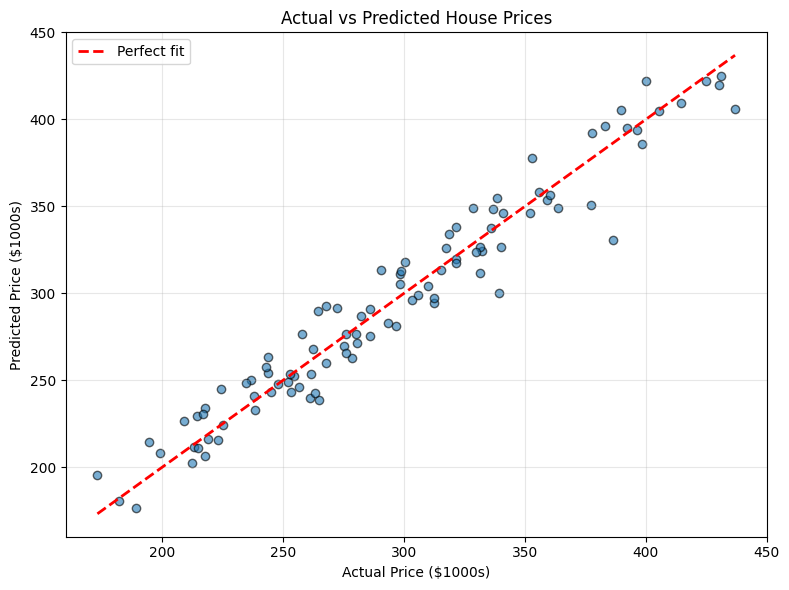


R² = 0.9463


In [8]:
# Get fitted values for training data
y_pred = result.predict(X)

# Create plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f"\nR² = {r2:.4f}")

## Next Steps

- **More on GLMs:** See `01_regression/01_linear_gaussian_glm.ipynb` for detailed GLM tutorial
- **Non-linear relationships:** Try `00_quickstart/02_first_gam.ipynb` to add smooth curves
- **Grouped data:** Try `00_quickstart/03_first_gamm.ipynb` for hierarchical models

## Resources

- [Aurora-GLM Documentation](https://github.com/Matcraft94/Aurora-GLM)
- [GLM Theory](https://en.wikipedia.org/wiki/Generalized_linear_model)